In [41]:
# All auxiliary code is in ../src

import sys

sys.path.append("../src/")

import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
from distribution_utility import stats_and_distribution

races = pd.read_csv('../dataset/races.csv', sep=",")
cyclists = pd.read_csv('../dataset/cyclists.csv', sep=",")

## Delta

Dobbiamo gestire i casi in cui il delta non ha un comportamento crescente. Ciò risolve i casi errati per il delta, sia che siano negativi sia che siano semanticamente non corretti, come posizione inferiore e anche delta inferiore <br>
Possiamo vedere che le righe il cui delta non rispetta un comporamente crescente sono molte

In [42]:
# Crea una nuova colonna per gli errori e inizializzala a False
races['delta_error'] = False

# Funzione per calcolare il massimo tra tutti i precedenti per ogni gruppo
def check_monotonic_errors(group):
    # Ordina il gruppo per posizione
    group = group.sort_values(by='position')
    # Calcola il massimo progressivo tra tutti i valori precedenti (eccetto il valore corrente)
    group['max_previous'] = group['delta'].cummax().shift(1)
    # Verifica se ogni valore è minore del massimo tra i precedenti
    group['delta_error'] = group['delta'] < group['max_previous']
    # Restituisce il gruppo modificato
    return group

# Applica la funzione a ciascun gruppo separato da '_url'
races = races.groupby('_url').apply(check_monotonic_errors).reset_index(drop=True)

races[races['delta_error'] == True]


/tmp/ipykernel_1139/4079492538.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  races = races.groupby('_url').apply(check_monotonic_errors).reset_index(drop=True)


,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta,delta_error,max_previous
10893,dauphine/2006/stage-2,Critérium du Dauphiné Libéré,50.0,NaN,203000.0,NaN,NaN,800,NaN,2006-06-06 04:51:16,133,christophe-moreau,35.0,True,False,False,sweden-2010,323.0,True,366.0
10901,dauphine/2006/stage-2,Critérium du Dauphiné Libéré,50.0,NaN,203000.0,NaN,NaN,800,NaN,2006-06-06 04:51:16,141,jorg-ludewig,31.0,True,False,False,NaN,323.0,True,399.0
12610,dauphine/2007/stage-7,Critérium du Dauphiné Libéré,50.0,NaN,129000.0,NaN,NaN,816,NaN,2007-06-17 02:56:10,16,ludovic-turpin,32.0,True,False,False,c-a-1978,37.0,True,46.0
12852,dauphine/2008/stage-2,Critérium du Dauphiné Libéré,50.0,NaN,194000.0,NaN,NaN,644,NaN,2008-06-09 04:46:40,2,bjorn-schroder,28.0,True,False,False,NaN,4.0,True,6.0
12853,dauphine/2008/stage-2,Critérium du Dauphiné Libéré,50.0,NaN,194000.0,NaN,NaN,644,NaN,2008-06-09 04:46:40,3,fabian-wegmann,28.0,True,False,False,o.n.c.e.-eroski-2003,4.0,True,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584457,vuelta-a-espana/2022/stage-2,La Vuelta ciclista a España,80.0,100.0,175100.0,518.0,1.0,968,24.0,2022-08-20 03:49:34,173,edoardo-zambanini,21.0,True,False,False,new-zealand-2020,0.0,True,142.0
584458,vuelta-a-espana/2022/stage-2,La Vuelta ciclista a España,80.0,100.0,175100.0,518.0,1.0,968,24.0,2022-08-20 03:49:34,174,daryl-impey,38.0,True,False,False,slovakia-2008,0.0,True,142.0
584459,vuelta-a-espana/2022/stage-2,La Vuelta ciclista a España,80.0,100.0,175100.0,518.0,1.0,968,24.0,2022-08-20 03:49:34,175,jan-hirt,31.0,True,False,False,carlos-cycles-1975,0.0,True,142.0
584460,vuelta-a-espana/2022/stage-2,La Vuelta ciclista a España,80.0,100.0,175100.0,518.0,1.0,968,24.0,2022-08-20 03:49:34,176,gerben-thijssen,24.0,True,False,False,carlos-cycles-1975,0.0,True,142.0


Ovviamente questo controllo individua anche tutte le righe con un delta con valore negativo: non esistono righe senza errore con delta negativo

In [43]:
races[(races['delta_error'] == False) & (races['delta'] < 0)]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta,delta_error,max_previous


Vediamo come varia la distribuzione imputando i valori e determinando il delta come il massimo tra previous e next per ciascun valore

Description of attribute 'delta_log':


/tmp/ipykernel_1139/3225677642.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  correct_rows['delta_log'] = np.log(correct_rows['delta'].replace(0, np.nan))


count    467366.000000
mean          5.354865
std           1.652107
min           0.000000
25%           4.276666
50%           5.697093
75%           6.673298
max          11.027556
Name: delta_log, dtype: float64


Unique values:
[       nan 3.09104245 3.49650756 ... 7.784057   7.80547463 7.81318727]

Null values: 119260 over 586626 records - (20.33%)

Top 5 common value:
delta_log
0.693147    3624
1.609438    3295
1.098612    3163
1.791759    2971
1.386294    2858
Name: count, dtype: int64


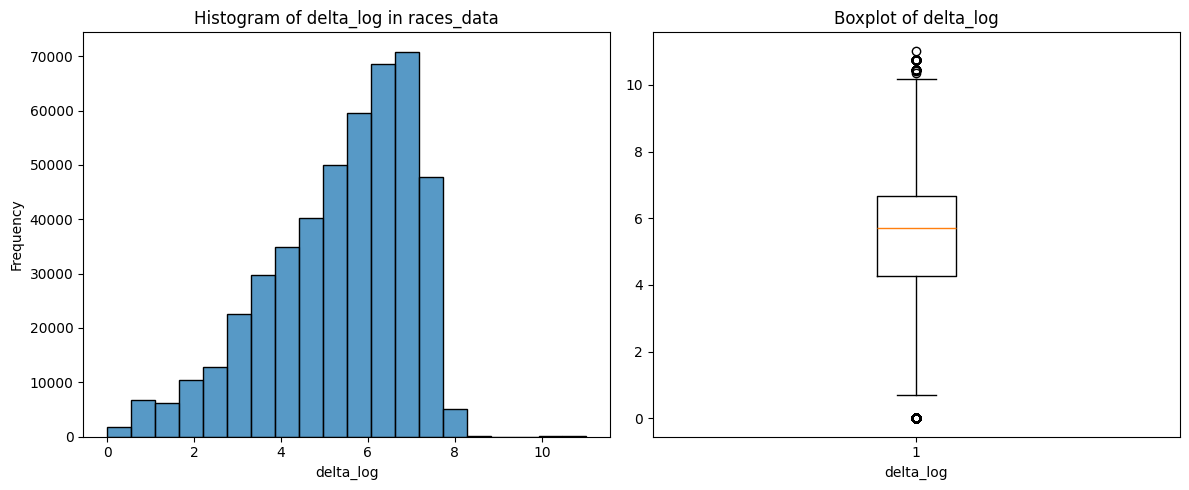

Outliers in delta_log: [0.0, 10.408496290980555, 10.456165040324679, 10.355836246543143, 10.744623610809523, 10.449381047562612, 11.027556389563637]
Description of attribute 'delta':


count    586626.000000
mean        419.822066
std         841.405594
min           0.000000
25%          11.000000
50%         158.000000
75%         627.000000
max       61547.000000
Name: delta, dtype: float64


Unique values:
[   0.   22.   33. ... 2402. 2454. 2473.]

Null values: 0 over 586626 records - (0.00%)

Top 5 common value:
delta
0.0    119260
2.0      3624
5.0      3295
3.0      3163
6.0      2971
Name: count, dtype: int64


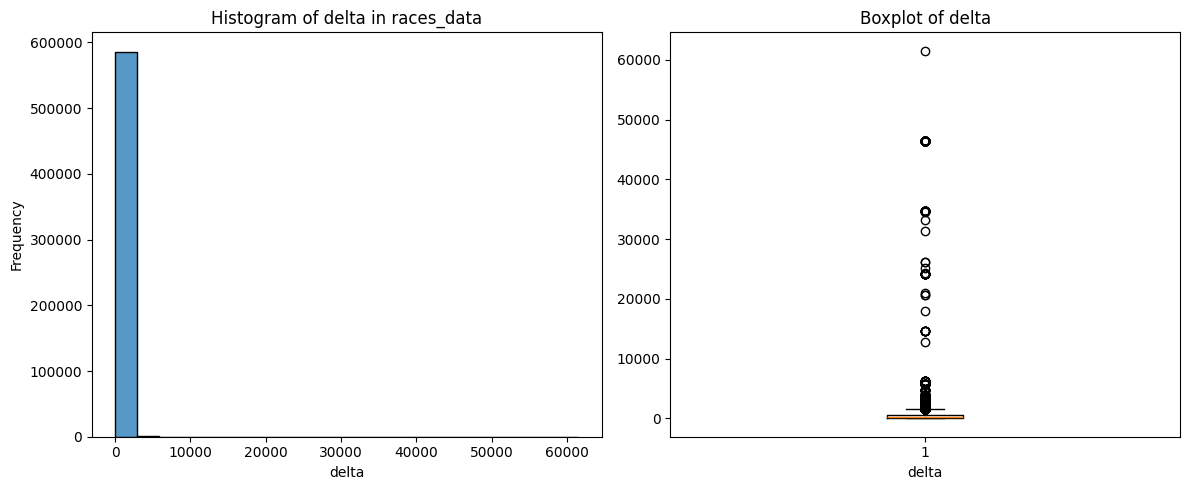

Outliers in delta: [2048.0, 2049.0, 2050.0, 2051.0, 2052.0, 2053.0, 2054.0, 2055.0, 2056.0, 2057.0, 2058.0, 2059.0, 2060.0, 2061.0, 2062.0, 2063.0, 2064.0, 2065.0, 2066.0, 2067.0, 2068.0, 2069.0, 2070.0, 2071.0, 2072.0, 2073.0, 2074.0, 2075.0, 2076.0, 2077.0, 2078.0, 2079.0, 2080.0, 2081.0, 2082.0, 2083.0, 2084.0, 2085.0, 2086.0, 2087.0, 2088.0, 2089.0, 2090.0, 2091.0, 2092.0, 2093.0, 2094.0, 2095.0, 2096.0, 2097.0, 2098.0, 2099.0, 2100.0, 2101.0, 2102.0, 2103.0, 2105.0, 2106.0, 2107.0, 2108.0, 2109.0, 2110.0, 2111.0, 2112.0, 2113.0, 2114.0, 2115.0, 2116.0, 2117.0, 2118.0, 2119.0, 2120.0, 2121.0, 2122.0, 2123.0, 2124.0, 2125.0, 2126.0, 2127.0, 2128.0, 2129.0, 2130.0, 2131.0, 2132.0, 2133.0, 2134.0, 2135.0, 2136.0, 2137.0, 2138.0, 2139.0, 2140.0, 2141.0, 2142.0, 2143.0, 2144.0, 2145.0, 2146.0, 2147.0, 2148.0, 2149.0, 2150.0, 2151.0, 2152.0, 2153.0, 2154.0, 2155.0, 61547.0, 2157.0, 2158.0, 2159.0, 2160.0, 2156.0, 2162.0, 2163.0, 2164.0, 2165.0, 2166.0, 2167.0, 2168.0, 2169.0, 2170.0, 217

In [44]:
import numpy as np


correct_rows = races[(races['delta_error'] == False)]
correct_rows['delta_log'] = np.log(correct_rows['delta'].replace(0, np.nan))
stats_and_distribution(correct_rows, 'delta_log', attr_type='numerical')
stats_and_distribution(correct_rows, 'delta', attr_type='numerical')

In [46]:
# Funzione per calcolare il massimo tra tutti i precedenti per ogni gruppo
def adjust_monotonic_errors(group):
    # Ordina il gruppo per posizione
    group = group.sort_values(by='position')
    mask = group['delta_error'] == True
    # Calcola il massimo progressivo tra tutti i valori precedenti e il successivo
    correct_delta = group['delta'].cummax().shift(-1)
    # Riempie eventuali NaN nell'ultimo valore con l'ultimo valore valido
    correct_delta = correct_delta.ffill() 
    # Verifica se ogni valore è minore del massimo tra i precedenti
    group.loc[mask, 'delta'] = correct_delta[mask]
    # Restituisce il gruppo modificato
    return group

# Applica la funzione a ciascun gruppo separato da '_url'
races = races.groupby('_url').apply(adjust_monotonic_errors).reset_index(drop=True)

/tmp/ipykernel_1139/3605015566.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  races = races.groupby('_url').apply(adjust_monotonic_errors).reset_index(drop=True)


Controlliamo se abbiamo corretto errori sul valore delta

In [47]:
# Verifica se la colonna 'delta' è monotona crescente per ciascun gruppo
monotonic_status = races.groupby('_url')['delta'].apply(lambda x: x.is_monotonic_increasing)

# Mostra il risultato
print("Tutti i gruppi sono monotoni crescenti:",  monotonic_status.all())

Tutti i gruppi sono monotoni crescenti: True


Controlliamo anche con la funzione prima usata e vediamo che nessun record verrà ritornato

In [48]:
# Applica la funzione a ciascun gruppo separato da '_url'
races = races.groupby('_url').apply(check_monotonic_errors).reset_index(drop=True)

races[races['delta_error'] == True]

/tmp/ipykernel_1139/1280869726.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  races = races.groupby('_url').apply(check_monotonic_errors).reset_index(drop=True)


,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta,delta_error,max_previous


Analizziamo la distribuzione dopo correzione: gli outlier rimangono gli stessi e i quantili sono rispettati. In generale la distribuzione non è intaccata dalla trasformazione e siamo riusciti a risolvere il problema semantico!

Description of attribute 'delta':


count    589865.000000
mean        431.048699
std        1016.531650
min           0.000000
25%          11.000000
50%         158.000000
75%         626.000000
max       61547.000000
Name: delta, dtype: float64


Unique values:
[   0.   22.   33. ... 2402. 2454. 2473.]

Null values: 0 over 589865 records - (0.00%)

Top 5 common value:
delta
0.0    119269
2.0      3625
5.0      3295
6.0      3172
3.0      3163
Name: count, dtype: int64


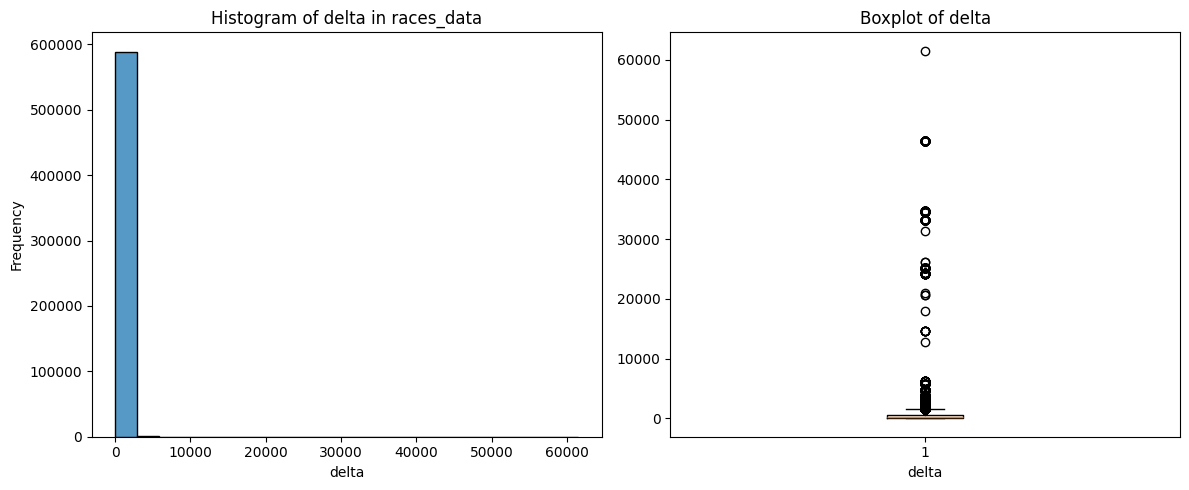

Outliers in delta: [2048.0, 2049.0, 2050.0, 2051.0, 2052.0, 2053.0, 2054.0, 2055.0, 2056.0, 2057.0, 2058.0, 2059.0, 2060.0, 2061.0, 2062.0, 2063.0, 2064.0, 2065.0, 2066.0, 2067.0, 2068.0, 2069.0, 2070.0, 2071.0, 2072.0, 2073.0, 2074.0, 2075.0, 2076.0, 2077.0, 2078.0, 2079.0, 2080.0, 2081.0, 2082.0, 2083.0, 2084.0, 2085.0, 2086.0, 2087.0, 2088.0, 2089.0, 2090.0, 2091.0, 2092.0, 2093.0, 2094.0, 2095.0, 2096.0, 2097.0, 2098.0, 2099.0, 2100.0, 2101.0, 2102.0, 2103.0, 2105.0, 2106.0, 2107.0, 2108.0, 2109.0, 2110.0, 2111.0, 2112.0, 2113.0, 2114.0, 2115.0, 2116.0, 2117.0, 2118.0, 2119.0, 2120.0, 2121.0, 2122.0, 2123.0, 2124.0, 2125.0, 2126.0, 2127.0, 2128.0, 2129.0, 2130.0, 2131.0, 2132.0, 2133.0, 2134.0, 2135.0, 2136.0, 2137.0, 2138.0, 2139.0, 2140.0, 2141.0, 2142.0, 2143.0, 2144.0, 2145.0, 2146.0, 2147.0, 2148.0, 2149.0, 2150.0, 2151.0, 2152.0, 2153.0, 2154.0, 2155.0, 61547.0, 2157.0, 2158.0, 2159.0, 2160.0, 2156.0, 2162.0, 2163.0, 2164.0, 2165.0, 2166.0, 2167.0, 2168.0, 2169.0, 2170.0, 217

count    470596.000000
mean          5.355478
std           1.654915
min           0.000000
25%           4.276666
50%           5.693732
75%           6.673298
max          11.027556
Name: delta_log, dtype: float64


Unique values:
[       nan 3.09104245 3.49650756 ... 7.784057   7.80547463 7.81318727]

Null values: 119269 over 589865 records - (20.22%)

Top 5 common value:
delta_log
0.693147    3625
1.609438    3295
1.791759    3172
1.098612    3163
1.386294    2858
Name: count, dtype: int64


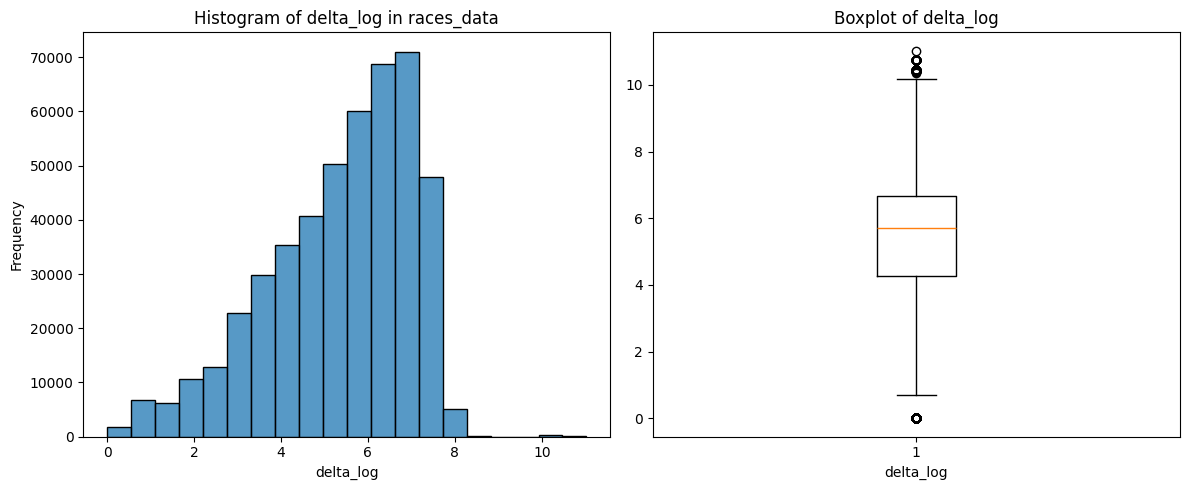

Outliers in delta_log: [0.0, 10.408496290980555, 10.456165040324679, 10.355836246543143, 10.744623610809523, 10.449381047562612, 11.027556389563637]


In [40]:
races['delta_log'] = np.log(races['delta'].replace(0, np.nan))
stats_and_distribution(races, 'delta', attr_type='numerical')
stats_and_distribution(races, 'delta_log', attr_type='numerical')

In [60]:
races = races.drop(columns=['delta_error', 'max_previous', 'delta_log'])